In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path

root_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils").exists()), None)
if root_path is None:
    raise FileNotFoundError("Could not locate project root containing 'utils' directory")
sys.path.append(str(root_path))

from utils.helpers import load_data

from scipy.stats import spearmanr, pearsonr

In [63]:
# Define consistent color palette for combined analysis
COLOR_COMBINED = '#06402B'    # Dark green for combined data
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Time analysis specific colors
COLOR_EXPECTED = '#A9A9A9'    # Dark grey for expected time
COLOR_FAST = '#FFD700'        # Yellow for faster than expected (< 85%)
COLOR_SLOW = '#FF4444'        # Red for slower than expected (> 115%)

# Time Analysis - Combined Data

Detailed analysis of time during the exam. Expected time vs. time taken task by task.

**Analysis focuses on:**
- Overall time distribution and patterns
- Expected vs. actual time per task
- Time deviations from expected values
- Rapid guessing patterns
- Temporal progression and fatigue effects

**Note:** This analysis only includes students without extra or incident time.

## 1. Data Loading

In [64]:
df = load_data("../data/cleaned_data/IN1020_2023_cleaned_data.csv")
df.head()

Data loaded successfully from ../data/cleaned_data/IN1020_2023_cleaned_data.csv


,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,gender,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,total_score
0,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg__9164195750 associableHotspot__146705536,63.0
1,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg_IA1701156824392d16c8498-010d-48e2-8773-...,63.0
2,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg__361670718761 associableHotspot45546867419,63.0
3,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg_IA1701156731070520d3d02-90c1-49b6-b58e-...,63.0
4,2023-12-11 08:00:12,2023-12-11 11:54:57,0,0,F,214,4.5,1.1,Dataformater,641,4.5,gapImg_IA1701156329933eb2abd04-c1f3-401f-847a-...,63.0


## 2. Data Preparation

In [65]:
df_time = df.groupby(['student_id', 'question_number']).agg({
    'gender': 'first',
    'max_question_score': 'first',
    'auto_score_per_question': 'first',
    'question_duration_sec': 'first',
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'extra_time_mins': 'first',
    'incident_time_mins': 'first',
    'total_score': 'first'
}).reset_index()

df_time['time_taken_exam_min'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)
df_time = df_time.drop(columns=['exam_start_time', 'exam_end_time'])

df_time['expected_time_per_question_sec'] = 144 * df_time['max_question_score']  # Assuming 144 sec (2.4 minutes) per point since total exam time is 240 minutes for 100 points

df_time.head()

,student_id,question_number,gender,max_question_score,auto_score_per_question,question_duration_sec,extra_time_mins,incident_time_mins,total_score,time_taken_exam_min,expected_time_per_question_sec
0,1,1.1,M,4.5,4.5,180,0,0,69.33,230.05,648.0
1,1,1.2,M,2.0,2.0,181,0,0,69.33,230.05,288.0
2,1,1.3,M,1.5,1.0,222,0,0,69.33,230.05,216.0
3,1,1.4,M,2.0,2.0,231,0,0,69.33,230.05,288.0
4,1,1.5,M,3.0,3.0,285,0,0,69.33,230.05,432.0


## 3. Data Exploration

In [66]:
extra_time_students_data = df_time[(df_time['extra_time_mins'] != 0) | (df_time['incident_time_mins'] != 0)]

extra_time_students_count = extra_time_students_data.groupby('student_id').agg({
    'extra_time_mins': 'first',
    'incident_time_mins': 'first'
}).reset_index()

counter1 = 0
counter2 = 0

for i in extra_time_students_count['extra_time_mins']:
    if i != 0:
        counter1 += 1

for i in extra_time_students_count['incident_time_mins']:
    if i != 0:
        counter2 += 1

print(f"There are {counter1} students with extra_time_mins (given before the exam).")
print(f"There are {counter2} students with incident_time_mins (given during the exam).")

There are 0 students with extra_time_mins (given before the exam).
There are 14 students with incident_time_mins (given during the exam).


In [67]:
# Description and exploration of time taken column
df_time[['time_taken_exam_min']].describe()

,time_taken_exam_min
count,18290.000000
mean,205.842475
std,43.911609
min,44.580000
25%,180.420000
50%,226.460000
75%,239.020000
max,300.670000


## 5. Expected vs Actual Time Per Task

In [68]:
# Description and exploration of specific columns
df_time[['expected_time_per_question_sec', 'question_duration_sec']].describe()

,expected_time_per_question_sec,question_duration_sec
count,18290.000000,18290.000000
mean,464.516129,385.951941
std,163.412500,376.391336
min,144.000000,0.000000
25%,288.000000,144.000000
50%,432.000000,278.000000
75%,576.000000,502.000000
max,720.000000,5902.000000


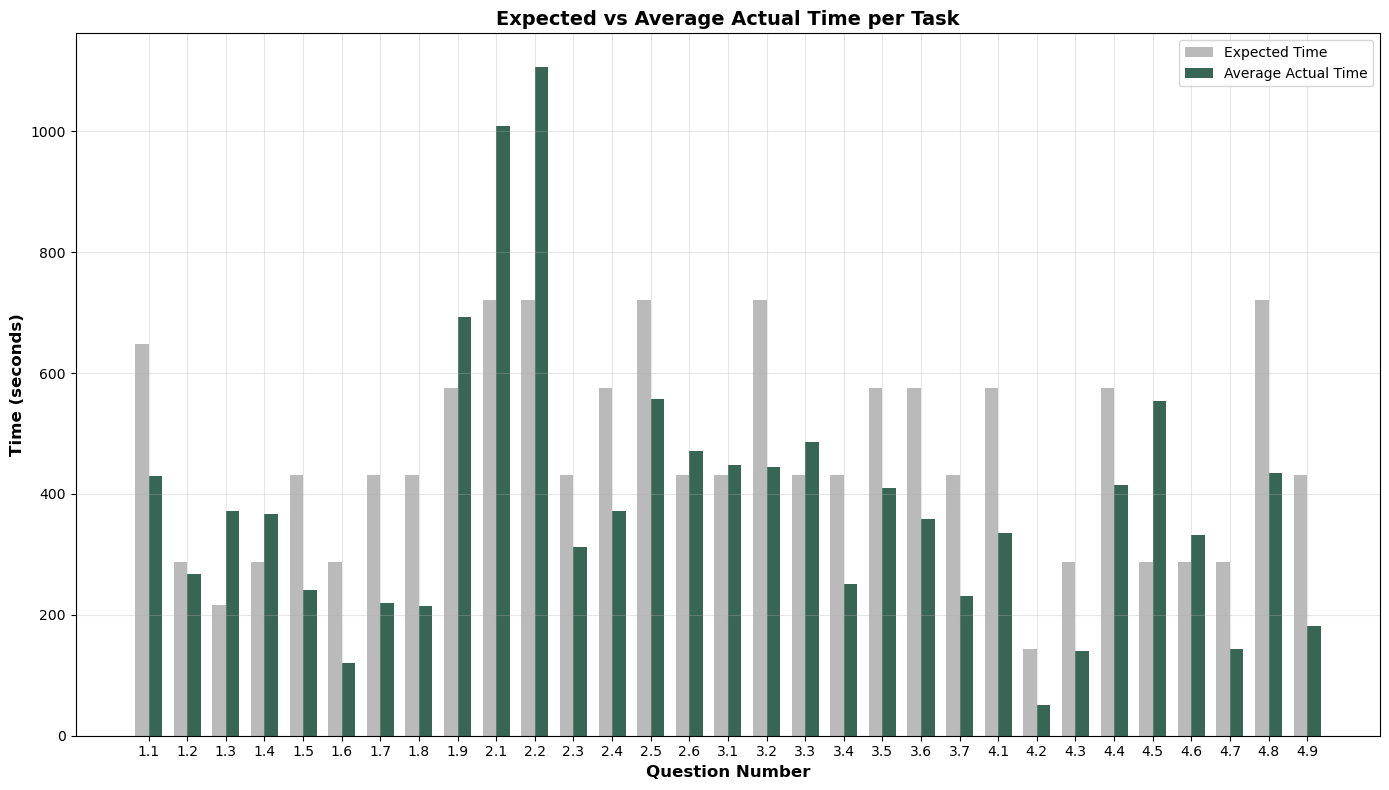

In [69]:
# Bar plots comparing expected vs actual time per task
time_by_task = df_time.groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

x = time_by_task['question_number']
width = 0.35
x_pos = range(len(x))

bars1 = ax.bar([i - width/2 for i in x_pos], time_by_task['expected_time_per_question_sec'], 
               width, label='Expected Time', color=COLOR_EXPECTED, alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x_pos], time_by_task['question_duration_sec'], 
               width, label='Average Actual Time', color=COLOR_COMBINED, alpha=0.8)

ax.set_xlabel('Question Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Expected vs Average Actual Time per Task', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Time Deviation Analysis

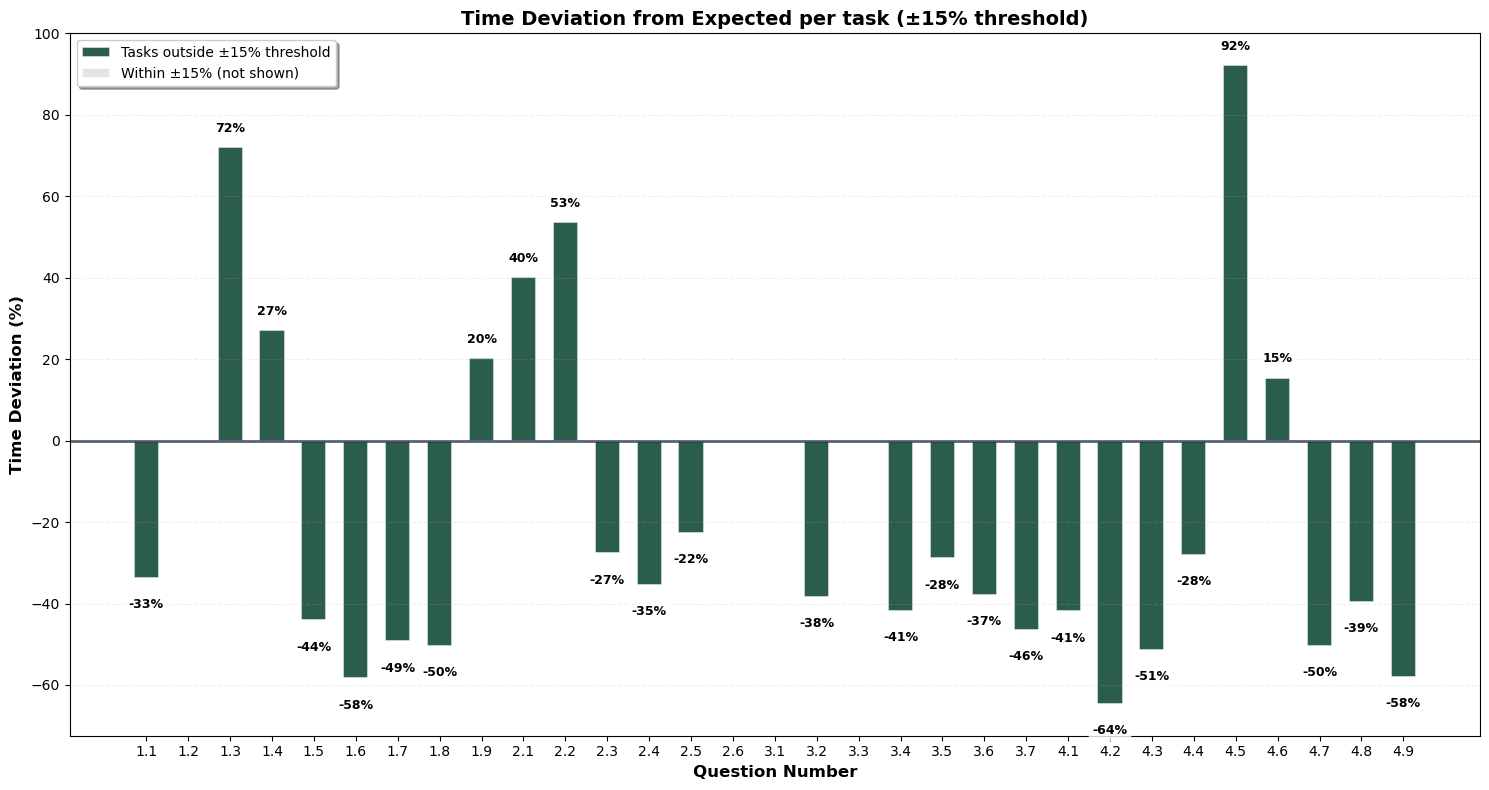


=== TIME DEVIATION SUMMARY ===
Tasks outside ±15% threshold: 27/31 (87.1%)
Tasks taking longer than expected (>15%): 7
Tasks taking less time than expected (<-15%): 20
  Slowest tasks: 4.5, 1.3, 2.2
  Fastest tasks: 4.2, 1.6, 4.9


In [70]:
# Time deviation analysis - showing only deviations outside ±15% threshold
def calculate_time_deviations(data):
    """Calculate time deviations from expected time"""
    time_by_task = data.groupby('question_number').agg({
        'expected_time_per_question_sec': 'first',
        'question_duration_sec': 'mean'
    }).reset_index()
    
    # Calculate percentage deviation
    time_by_task['deviation_pct'] = ((time_by_task['question_duration_sec'] - time_by_task['expected_time_per_question_sec']) / 
                                    time_by_task['expected_time_per_question_sec']) * 100
    
    # Only show deviations outside ±15% threshold
    time_by_task['deviation_pct_filtered'] = time_by_task['deviation_pct'].where(
        (time_by_task['deviation_pct'] < -15) | (time_by_task['deviation_pct'] > 15), 0
    )
    
    return time_by_task

deviation_combined = calculate_time_deviations(df_time)

# Create deviation plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

x = deviation_combined['question_number']
y = deviation_combined['deviation_pct_filtered']
x_pos = range(len(x))

colors = [COLOR_COMBINED if val != 0 else '#E0E0E0' for val in y]

bars = ax.bar(x_pos, y, width=0.6, color=colors, alpha=0.85, 
              edgecolor='white', linewidth=1.2)

ax.axhline(y=0, color='#2C3E50', linestyle='-', linewidth=2, alpha=0.8)

ax.set_xlabel('Question Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Time Deviation (%)', fontsize=12, fontweight='bold')
ax.set_title('Time Deviation from Expected per task (±15% threshold)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2, axis='y', linestyle='--')

ax.set_xticks(x_pos)
ax.set_xticklabels(x, fontsize=10, rotation=0)

# Add value labels on bars
for bar, value in zip(bars, y):
    if abs(value) > 1:
        height = bar.get_height()
        label_y = height + (3 if height > 0 else -5)
        
        ax.text(bar.get_x() + bar.get_width()/2., label_y,
               f'{int(height)}%', ha='center', 
               va='bottom' if height > 0 else 'top',
               fontsize=9, fontweight='bold', 
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_COMBINED, alpha=0.85, edgecolor='white', linewidth=1.2, label='Tasks outside ±15% threshold'),
    Patch(facecolor='#E0E0E0', alpha=0.85, edgecolor='white', linewidth=1.2, label='Within ±15% (not shown)')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True, 
         fancybox=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== TIME DEVIATION SUMMARY ===")
outside_threshold = deviation_combined[abs(deviation_combined['deviation_pct']) > 15]
slower_tasks = deviation_combined[deviation_combined['deviation_pct'] > 15]
faster_tasks = deviation_combined[deviation_combined['deviation_pct'] < -15]

print(f"Tasks outside ±15% threshold: {len(outside_threshold)}/{len(deviation_combined)} ({len(outside_threshold)/len(deviation_combined)*100:.1f}%)")
print(f"Tasks taking longer than expected (>15%): {len(slower_tasks)}")
print(f"Tasks taking less time than expected (<-15%): {len(faster_tasks)}")

if len(slower_tasks) > 0:
    print(f"  Slowest tasks: {', '.join(map(str, slower_tasks.nlargest(3, 'deviation_pct')['question_number'].tolist()))}")
if len(faster_tasks) > 0:
    print(f"  Fastest tasks: {', '.join(map(str, faster_tasks.nsmallest(3, 'deviation_pct')['question_number'].tolist()))}")

## 7. Rapid Guessing Patterns

In [71]:
def analyze_rapid_guessing(df, rapid_guess_threshold=15):
    """Analyze rapid guessing patterns in exam data"""
    df_rg = df.copy()
    df_rg['is_rapid_guess'] = df_rg['question_duration_sec'] < rapid_guess_threshold
    
    # Student-level statistics
    student_rapid_stats = df_rg.groupby('student_id').agg({
        'is_rapid_guess': ['sum', 'count', 'mean'],
        'total_score': 'first'
    }).reset_index()
    
    student_rapid_stats.columns = ['student_id', 'rapid_guess_count', 'total_questions', 
                                   'rapid_guess_percentage', 'total_score']
    student_rapid_stats['rapid_guess_percentage'] *= 100
    
    # Correlations
    pearson_corr, pearson_p = pearsonr(student_rapid_stats['rapid_guess_percentage'], 
                                      student_rapid_stats['total_score'])
    spearman_corr, spearman_p = spearmanr(student_rapid_stats['rapid_guess_percentage'], 
                                         student_rapid_stats['total_score'])
    
    # Question-level statistics
    question_rapid_stats = df_rg.groupby('question_number').agg({
        'is_rapid_guess': ['sum', 'count', 'mean'],
        'auto_score_per_question': 'mean',
        'max_question_score': 'first'
    }).reset_index()
    
    question_rapid_stats.columns = ['question_number', 'rapid_guess_count', 'total_attempts',
                                   'rapid_guess_rate', 'avg_score_on_question', 'max_score']
    question_rapid_stats['rapid_guess_rate'] *= 100
    question_rapid_stats = question_rapid_stats.sort_values('rapid_guess_rate', ascending=False)
    
    results = {
        'student_stats': student_rapid_stats,
        'question_stats': question_rapid_stats,
        'correlations': {
            'pearson': {'correlation': pearson_corr, 'p_value': pearson_p},
            'spearman': {'correlation': spearman_corr, 'p_value': spearman_p}
        },
        'threshold': rapid_guess_threshold
    }
    
    # Print summary
    print(f"=== RAPID GUESSING ANALYSIS (Threshold: <{rapid_guess_threshold} seconds) ===")
    print(f"Total students analyzed: {len(student_rapid_stats)}")
    print(f"Total questions analyzed: {len(question_rapid_stats)}")
    print(f"Overall rapid guess rate: {df_rg['is_rapid_guess'].mean()*100:.1f}%")
    
    print(f"\n--- STUDENT-LEVEL STATISTICS ---")
    print(f"Average rapid guess percentage per student: {student_rapid_stats['rapid_guess_percentage'].mean():.1f}%")
    print(f"Students with >50% rapid guesses: {len(student_rapid_stats[student_rapid_stats['rapid_guess_percentage'] > 50])}")
    print(f"Students with 0% rapid guesses: {len(student_rapid_stats[student_rapid_stats['rapid_guess_percentage'] == 0])}")
    
    print(f"\n--- CORRELATION WITH SCORES ---")
    print(f"Pearson correlation: r = {pearson_corr:.3f}, p = {pearson_p:.3f}")
    print(f"Spearman correlation: ρ = {spearman_corr:.3f}, p = {spearman_p:.3f}")
    
    print(f"\n--- TOP 5 QUESTIONS WITH MOST RAPID GUESSES ---")
    top_5_rapid = question_rapid_stats.head(5)
    for _, row in top_5_rapid.iterrows():
        print(f"{float(row['question_number'])}: {row['rapid_guess_rate']:.1f}% rapid guesses "
              f"({row['rapid_guess_count']}/{row['total_attempts']} attempts)")
    
    return results

rapid_guess_results = analyze_rapid_guessing(df_time, rapid_guess_threshold=15)

=== RAPID GUESSING ANALYSIS (Threshold: <15 seconds) ===
Total students analyzed: 590
Total questions analyzed: 31
Overall rapid guess rate: 1.2%

--- STUDENT-LEVEL STATISTICS ---
Average rapid guess percentage per student: 1.2%
Students with >50% rapid guesses: 0
Students with 0% rapid guesses: 399

--- CORRELATION WITH SCORES ---
Pearson correlation: r = -0.053, p = 0.197
Spearman correlation: ρ = 0.092, p = 0.026

--- TOP 5 QUESTIONS WITH MOST RAPID GUESSES ---
4.2: 29.3% rapid guesses (173.0/590.0 attempts)
4.7: 2.7% rapid guesses (16.0/590.0 attempts)
4.6: 1.2% rapid guesses (7.0/590.0 attempts)
4.3: 0.5% rapid guesses (3.0/590.0 attempts)
4.5: 0.5% rapid guesses (3.0/590.0 attempts)


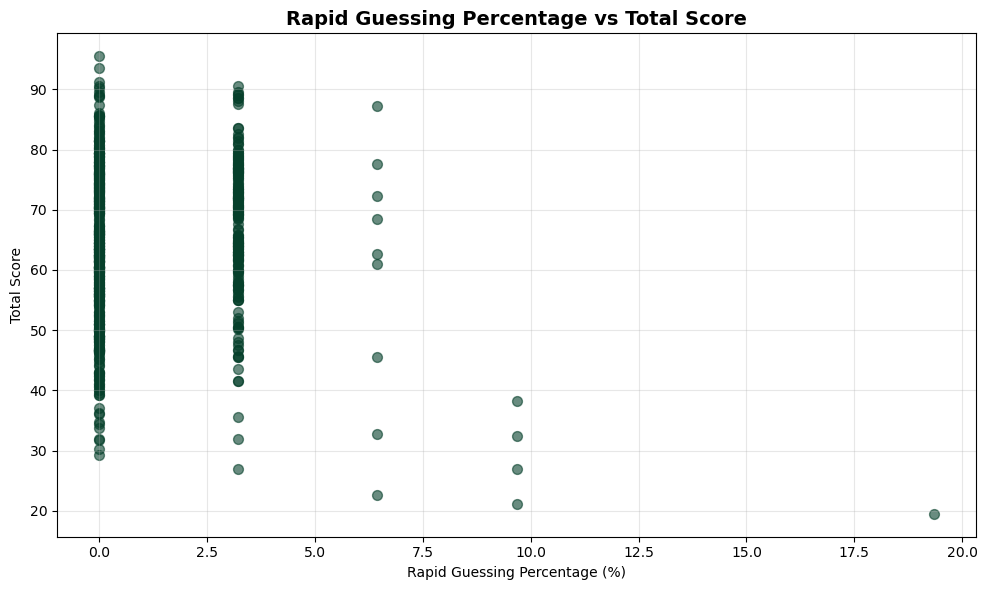

In [72]:
# Visualize rapid guessing vs scores
plt.figure(figsize=(10, 6))
plt.scatter(rapid_guess_results['student_stats']['rapid_guess_percentage'],
           rapid_guess_results['student_stats']['total_score'],
           alpha=0.6, color=COLOR_COMBINED, s=50)
plt.title('Rapid Guessing Percentage vs Total Score', fontsize=14, fontweight='bold')
plt.xlabel('Rapid Guessing Percentage (%)')
plt.ylabel('Total Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Temporal Progression Analysis

In [73]:
# Prepare temporal progression data
temporal_stats = df_time.groupby('question_number').agg({
    'question_duration_sec': ['mean', 'median', 'std', 'count'],
    'auto_score_per_question': ['mean', 'std'],
    'max_question_score': 'first',
    'expected_time_per_question_sec': 'first'
}).reset_index()

temporal_stats.columns = ['question_number', 'mean_time', 'median_time', 'std_time', 'count',
                         'mean_score', 'std_score', 'max_score', 'expected_time']

temporal_stats['accuracy_rate'] = (temporal_stats['mean_score'] / temporal_stats['max_score']) * 100
temporal_stats['time_deviation_pct'] = ((temporal_stats['mean_time'] - temporal_stats['expected_time']) / 
                                       temporal_stats['expected_time']) * 100

print("=== TEMPORAL PROGRESSION DATA ===")
print(f"Questions analyzed: {len(temporal_stats)}")
print(f"Total student responses: {temporal_stats['count'].sum()}")
print("\nFirst 10 questions:")
print(temporal_stats[['question_number', 'median_time', 'accuracy_rate', 'time_deviation_pct']].head(10))

=== TEMPORAL PROGRESSION DATA ===
Questions analyzed: 31
Total student responses: 18290

First 10 questions:
   question_number  median_time  accuracy_rate  time_deviation_pct
0              1.1        363.5      71.073446          -33.624451
1              1.2        198.5      90.000000           -7.211629
2              1.3        313.5      79.604520           72.085687
3              1.4        266.0      85.762712           27.115113
4              1.5        203.5      90.296610          -44.152542
5              1.6         89.0      96.271186          -58.364524
6              1.7        176.0      83.163842          -49.272599
7              1.8        175.0      66.271186          -50.411959
8              1.9        591.0      36.912288           20.345457
9              2.1        824.0      63.457627           40.201977


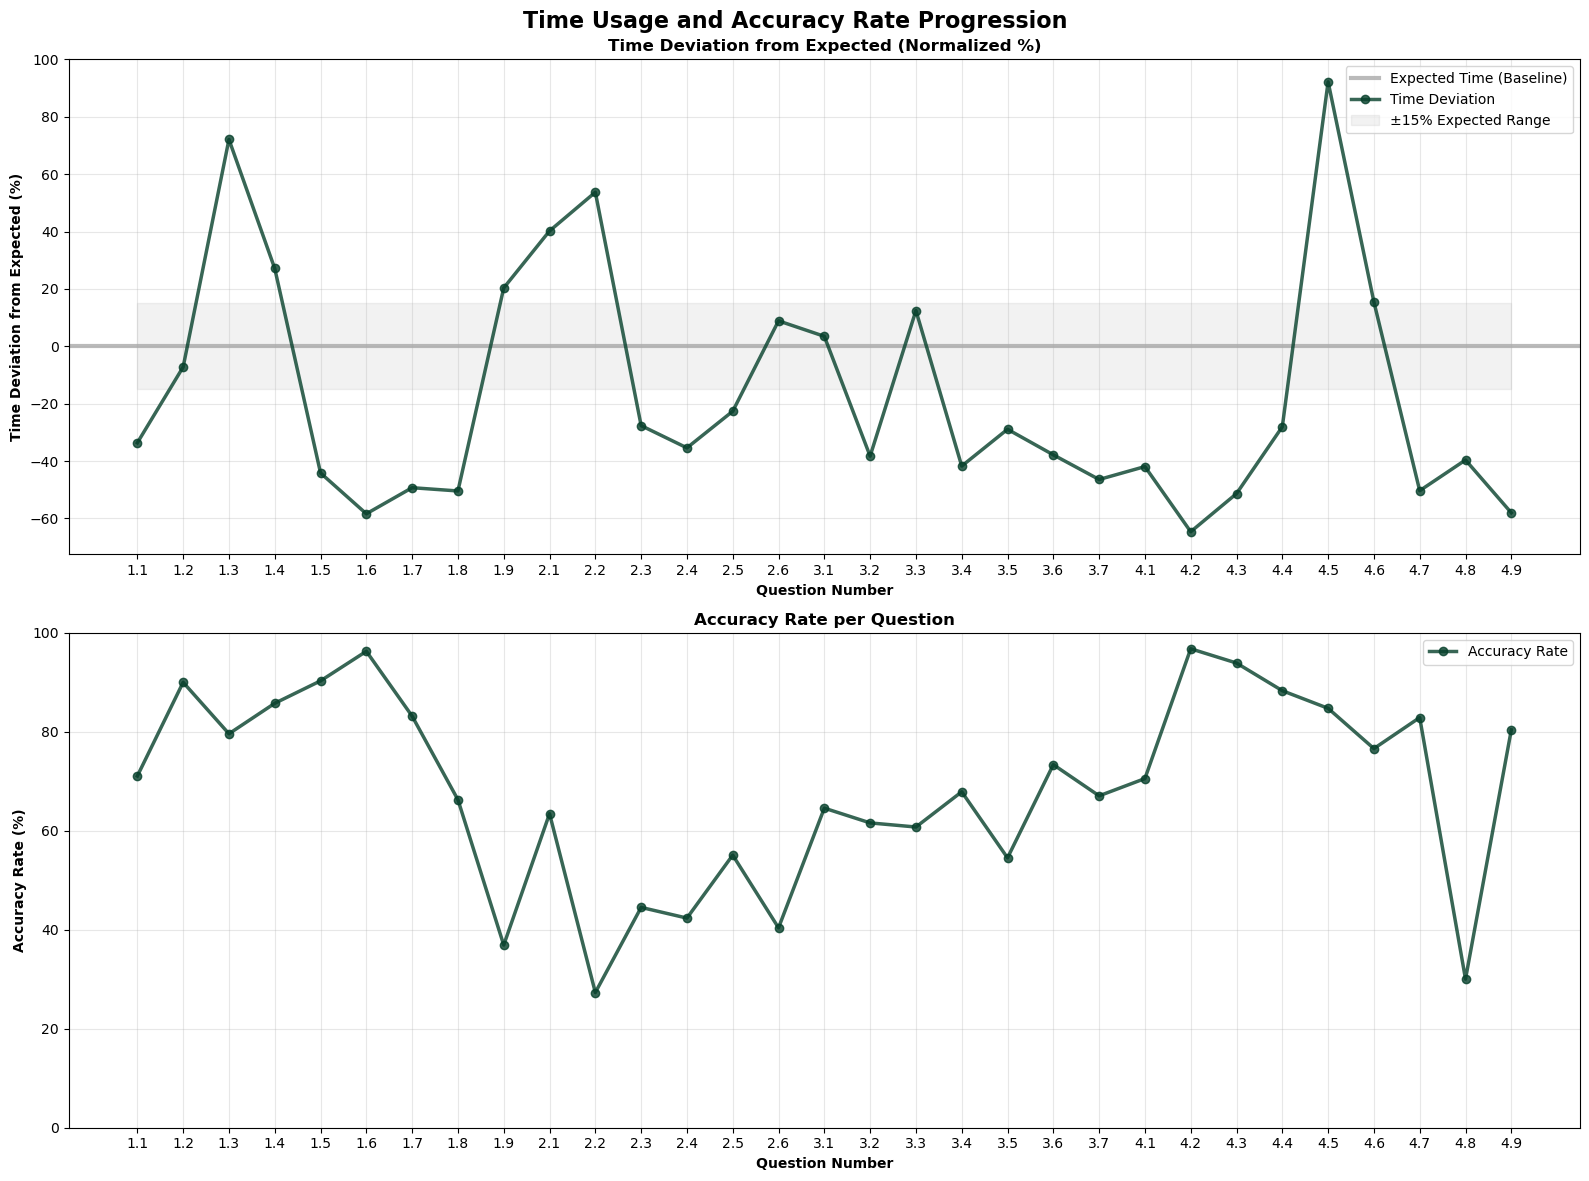

In [74]:
# Time progression visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Time Usage and Accuracy Rate Progression', fontsize=16, fontweight='bold')

x_positions = range(len(temporal_stats))

# Plot 1: Time Deviation from Expected
combined_deviation_pct = ((temporal_stats['mean_time'] - temporal_stats['expected_time']) / 
                          temporal_stats['expected_time']) * 100

axes[0].axhline(y=0, linestyle='-', linewidth=3, color=COLOR_EXPECTED, label='Expected Time (Baseline)', alpha=0.8)
axes[0].plot(x_positions, combined_deviation_pct, marker='o', linewidth=2.5, markersize=6, 
            color=COLOR_COMBINED, label='Time Deviation', alpha=0.8)

axes[0].fill_between(x_positions, [-15] * len(x_positions), [15] * len(x_positions), 
                     alpha=0.1, color='gray', label='±15% Expected Range')

axes[0].set_xlabel('Question Number', fontweight='bold')
axes[0].set_ylabel('Time Deviation from Expected (%)', fontweight='bold')
axes[0].set_title('Time Deviation from Expected (Normalized %)', fontweight='bold')
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(temporal_stats['question_number'])
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Accuracy Rate Progression
axes[1].plot(x_positions, temporal_stats['accuracy_rate'], marker='o', linewidth=2.5, markersize=6, 
            color=COLOR_COMBINED, label='Accuracy Rate', alpha=0.8)

axes[1].set_xlabel('Question Number', fontweight='bold')
axes[1].set_ylabel('Accuracy Rate (%)', fontweight='bold')
axes[1].set_title('Accuracy Rate per Question', fontweight='bold')
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(temporal_stats['question_number'])
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Time vs Accuracy Relationship

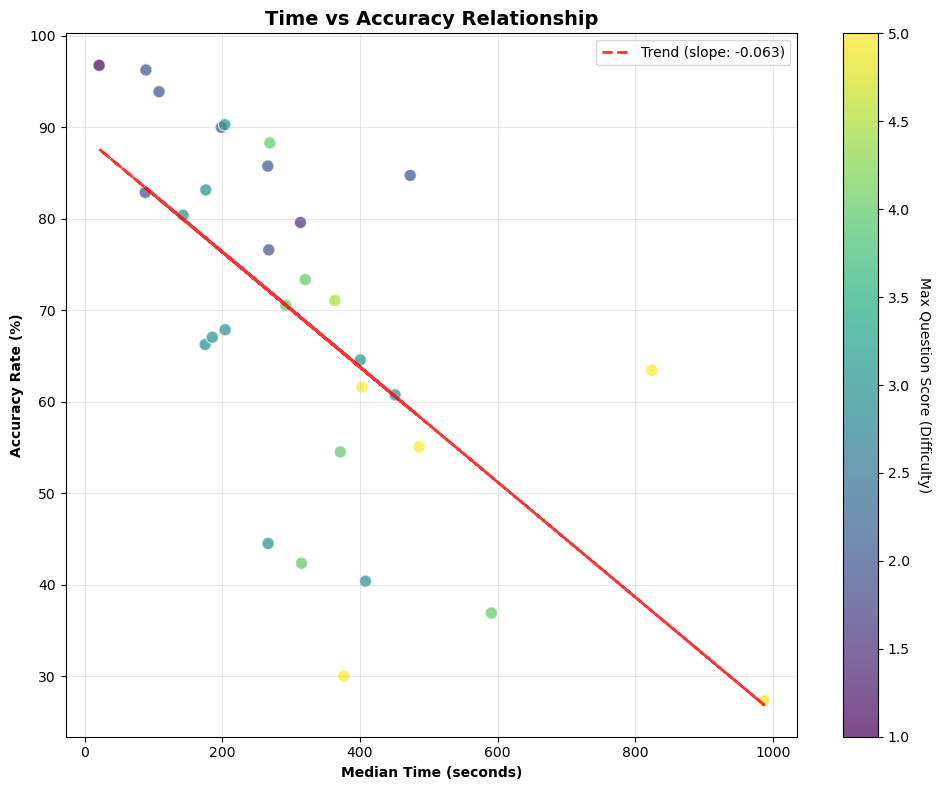


=== TIME VS ACCURACY TREND ===
Trend slope value: -0.0629
✗ NEGATIVE RELATIONSHIP (Weak): More time → Slightly lower accuracy


In [75]:
# Time vs Accuracy scatterplot
plt.figure(figsize=(10, 8))

scatter = plt.scatter(temporal_stats['median_time'], temporal_stats['accuracy_rate'],
                     c=temporal_stats['max_score'], s=80, alpha=0.7, 
                     cmap='viridis', edgecolor='white', linewidth=1)

cbar = plt.colorbar(scatter)
cbar.set_label('Max Question Score (Difficulty)', rotation=270, labelpad=15)

# Add trend line
z = np.polyfit(temporal_stats['median_time'], temporal_stats['accuracy_rate'], 1)
p = np.poly1d(z)
plt.plot(temporal_stats['median_time'], p(temporal_stats['median_time']), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend (slope: {z[0]:.3f})')

plt.xlabel('Median Time (seconds)', fontweight='bold')
plt.ylabel('Accuracy Rate (%)', fontweight='bold')
plt.title('Time vs Accuracy Relationship', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Interpret the trend
print("\n=== TIME VS ACCURACY TREND ===")
slope = z[0]
print(f"Trend slope value: {slope:.4f}")

if slope > 0.1:
    print("✓ POSITIVE RELATIONSHIP (Strong): More time → Higher accuracy")
elif slope > 0.01:
    print("✓ POSITIVE RELATIONSHIP (Weak): More time → Slightly higher accuracy")
elif slope < -0.1:
    print("✗ NEGATIVE RELATIONSHIP (Strong): More time → Lower accuracy")
elif slope < -0.01:
    print("✗ NEGATIVE RELATIONSHIP (Weak): More time → Slightly lower accuracy")
else:
    print("○ NO CLEAR RELATIONSHIP: Time and accuracy not strongly related")

## 10. Fatigue Detection Analysis

### Universal Fatigue Detection Analysis

This analysis uses a **universal grouping approach** that automatically adapts to different question numbering conventions:

**Float Format (e.g., 1.1, 1.2, 2.1, 2.2, 3.1, 3.2)**
- **Method**: Groups questions by part number (integer portion)
- **Example**: Part 1 = (1.1, 1.2, 1.3...), Part 2 = (2.1, 2.2, 2.3...), etc.
- **Advantage**: Respects the natural exam structure and intended groupings

**Integer Format (e.g., 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)**
- **Method**: Divides exam into 5 equal segments (20% each)
- **Example**: Segment 1 = (1-20%), Segment 2 = (21-40%), etc.
- **Advantage**: Creates balanced groups for temporal progression analysis

This approach ensures consistent and meaningful analysis across different exam formats while maintaining the ability to detect fatigue patterns, warm-up effects, and performance changes throughout the exam.

=== UNIVERSAL FATIGUE ANALYSIS ===
Grouping method: Part-based grouping (float format)

Segment Analysis:
   segment description question_range  question_count  avg_time  accuracy_rate
0        1      Part 1      Q1.1-Q1.9               9    324.76          74.01
1        2      Part 2      Q2.1-Q2.6               6    638.04          46.14
2        3      Part 3      Q3.1-Q3.7               7    375.44          64.02
3        4      Part 4      Q4.1-Q4.9               9    287.26          71.99


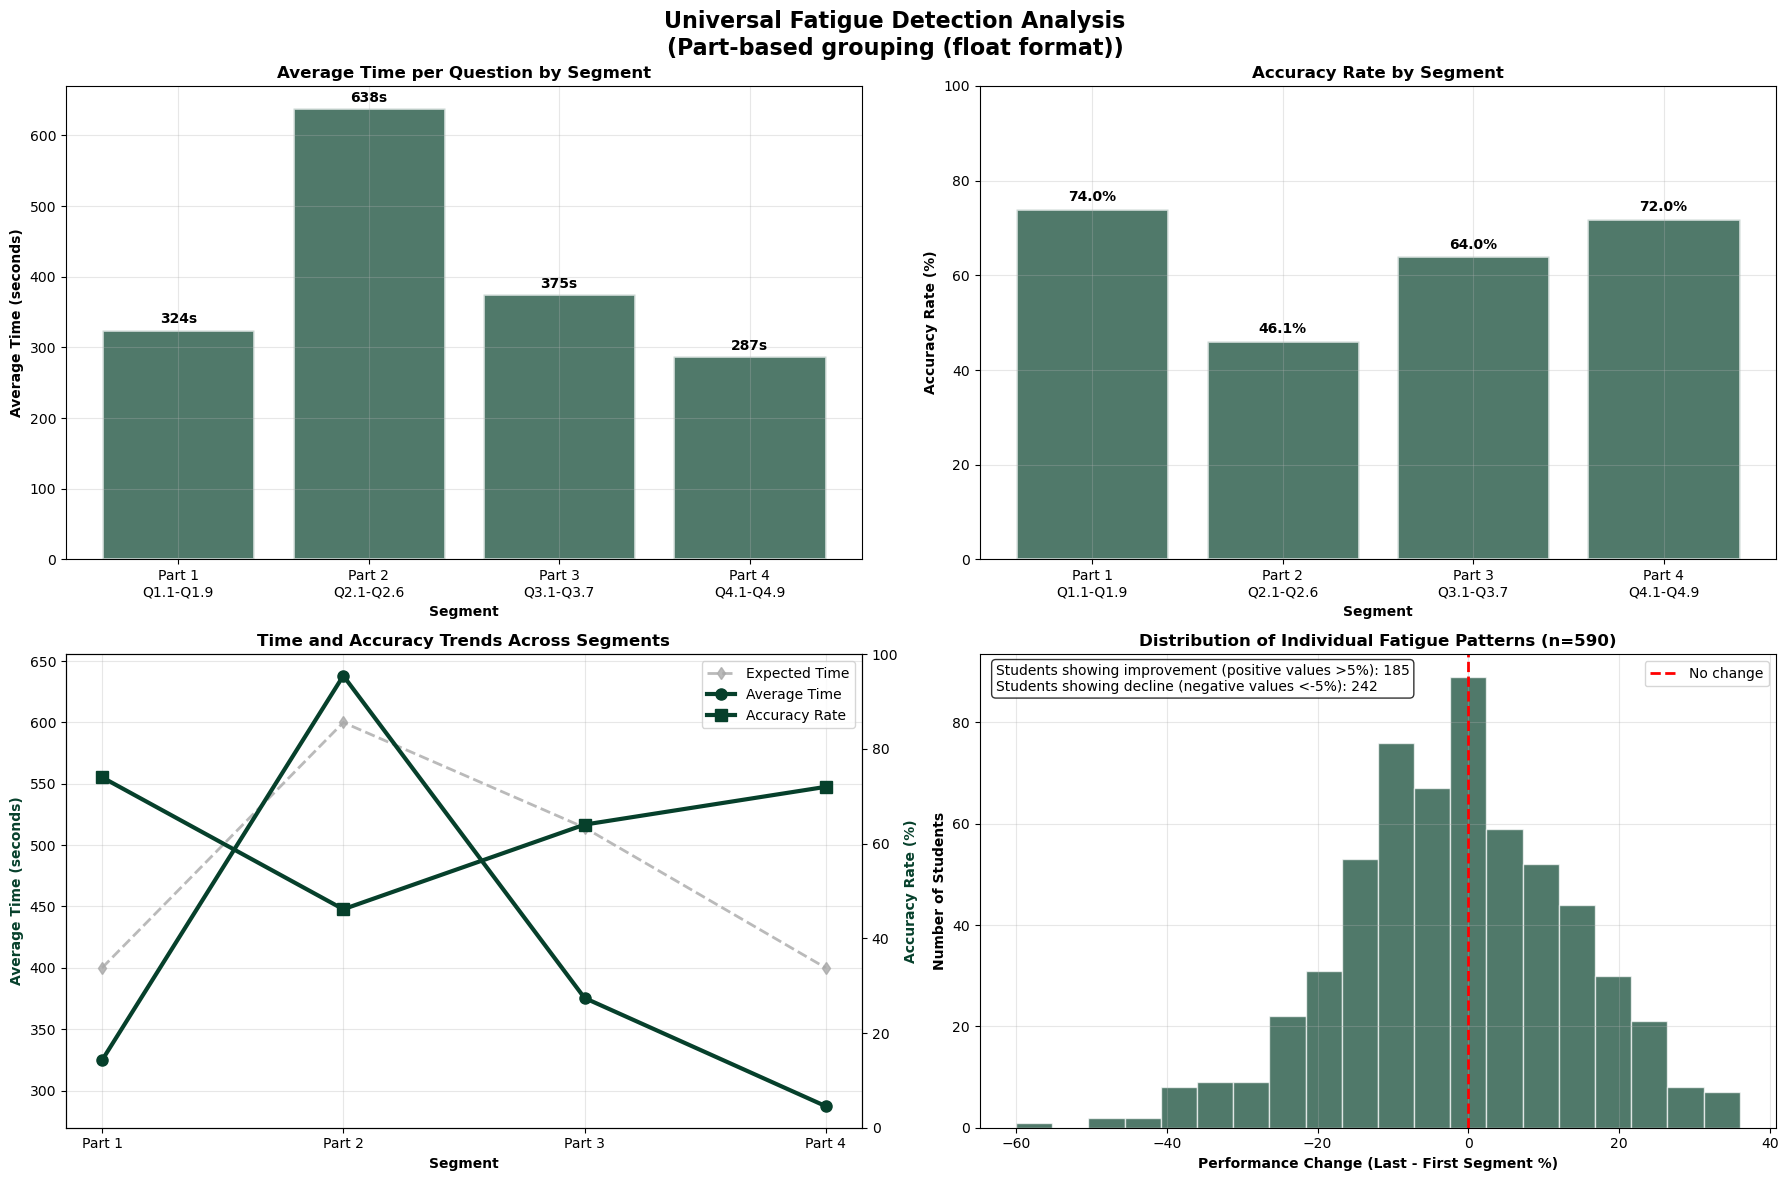


=== FATIGUE PATTERN SUMMARY ===
Grouping Method: Part-based grouping (float format)
Total segments analyzed: 4
Time change from first to last segment: -37.5 seconds
Accuracy change from first to last segment: -2.01%
• Time trend: Students are taking less time on later segments (possible rushing/giving up)
• Accuracy trend: Stable performance across segments
Students showing performance improvement (positive values): 185/590 (31.4%)
Students showing performance decline (negative values): 242/590 (41.0%)

Note: In this analysis:
• Positive values = Performance improved from first to last segment
• Negative values = Performance declined from first to last segment
• Zero = No change between first and last segments


In [76]:
# Universal Fatigue Detection Analysis
# Analyze if students perform worse on later items by creating groups based on question naming convention
# - For float questions (1.1, 1.2, 2.1, 2.2, etc.): Group by part number (integer portion)
# - For integer questions (1, 2, 3, 4, etc.): Divide into 5 equal parts (20% each)

def analyze_fatigue_patterns_universal(df_time, n_segments_for_integer=5):
    """
    Universal fatigue pattern analysis that adapts to different question numbering schemes.
    
    Parameters:
    -----------
    df_time : DataFrame
        The exam data with question_number column
    n_segments_for_integer : int, default=5
        Number of segments to create for integer-numbered questions (20% each)
    
    Returns:
    --------
    tuple : (segment_df, segments, grouping_method)
        - segment_df: DataFrame with statistics for each segment
        - segments: List of segment information
        - grouping_method: String describing the grouping method used
    """
    # Get unique question numbers and sort them
    questions = sorted(df_time['question_number'].unique())
    total_questions = len(questions)
    
    # Determine if questions use float format (parts) or integer format
    has_decimals = any(q != int(q) for q in questions if isinstance(q, (int, float)))
    
    if has_decimals:
        # Float format: Group by part number (1.1, 1.2 -> Part 1; 2.1, 2.2 -> Part 2, etc.)
        grouping_method = "Part-based grouping (float format)"
        
        # Extract unique parts
        parts = [int(q) for q in questions]
        unique_parts = sorted(set(parts))
        
        # Create segments based on parts
        segments = []
        for i, part in enumerate(unique_parts):
            part_questions = [q for q in questions if int(q) == part]
            segments.append({
                'segment': i + 1,
                'part_number': part,
                'questions': part_questions,
                'start_q': part_questions[0],
                'end_q': part_questions[-1],
                'question_count': len(part_questions),
                'description': f"Part {part}"
            })
    else:
        # Integer format: Divide into equal segments
        grouping_method = f"Equal division into {n_segments_for_integer} segments (integer format)"
        
        segment_size = total_questions // n_segments_for_integer
        segments = []
        
        for i in range(n_segments_for_integer):
            start_idx = i * segment_size
            if i == n_segments_for_integer - 1:  # Last segment includes remaining questions
                end_idx = total_questions
            else:
                end_idx = (i + 1) * segment_size
            
            segment_questions = questions[start_idx:end_idx]
            segments.append({
                'segment': i + 1,
                'part_number': None,  # No part concept for integer questions
                'questions': segment_questions,
                'start_q': segment_questions[0],
                'end_q': segment_questions[-1],
                'question_count': len(segment_questions),
                'description': f"Segment {i + 1} ({(i*100//n_segments_for_integer) + 1}-{((i+1)*100//n_segments_for_integer)}%)"
            })
    
    # Calculate statistics for each segment
    segment_stats = []
    for segment in segments:
        segment_data = df_time[df_time['question_number'].isin(segment['questions'])]
        
        stats = {
            'segment': segment['segment'],
            'description': segment['description'],
            'question_range': f"Q{segment['start_q']}-Q{segment['end_q']}",
            'question_count': segment['question_count'],
            'avg_time': segment_data['question_duration_sec'].mean(),
            'median_time': segment_data['question_duration_sec'].median(),
            'avg_score': segment_data['auto_score_per_question'].mean(),
            'avg_max_score': segment_data['max_question_score'].mean(),
            'student_count': segment_data['student_id'].nunique(),
            'total_responses': len(segment_data)
        }
        
        # Calculate accuracy rate
        stats['accuracy_rate'] = (stats['avg_score'] / stats['avg_max_score']) * 100
        
        segment_stats.append(stats)
    
    segment_df = pd.DataFrame(segment_stats)
    return segment_df, segments, grouping_method

# Perform universal fatigue analysis
fatigue_stats, exam_segments, grouping_method = analyze_fatigue_patterns_universal(df_time)

print("=== UNIVERSAL FATIGUE ANALYSIS ===")
print(f"Grouping method: {grouping_method}")
print("\nSegment Analysis:")
display_columns = ['segment', 'description', 'question_range', 'question_count', 'avg_time', 'accuracy_rate']
print(fatigue_stats[display_columns].round(2))

# Create enhanced fatigue visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Universal Fatigue Detection Analysis\n({grouping_method})', 
             fontsize=16, fontweight='bold')

# Plot 1: Average Time by Segment
ax1 = axes[0, 0]
bars1 = ax1.bar(fatigue_stats['segment'], fatigue_stats['avg_time'], 
                color=COLOR_COMBINED, alpha=0.7, edgecolor='white', linewidth=2)
ax1.set_xlabel('Segment', fontweight='bold')
ax1.set_ylabel('Average Time (seconds)', fontweight='bold')
ax1.set_title('Average Time per Question by Segment', fontweight='bold')
ax1.set_xticks(fatigue_stats['segment'])

# Create labels for x-axis based on grouping method
x_labels = []
for _, row in fatigue_stats.iterrows():
    if "Part" in row['description']:
        x_labels.append(f"{row['description']}\n{row['question_range']}")
    else:
        x_labels.append(f"{row['description']}\n{row['question_range']}")

ax1.set_xticklabels(x_labels, rotation=45 if len(x_labels) > 4 else 0, ha='right' if len(x_labels) > 4 else 'center')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}s', ha='center', va='bottom', fontweight='bold')

# Plot 2: Accuracy Rate by Segment
ax2 = axes[0, 1]
bars2 = ax2.bar(fatigue_stats['segment'], fatigue_stats['accuracy_rate'], 
                color=COLOR_COMBINED, alpha=0.7, edgecolor='white', linewidth=2)
ax2.set_xlabel('Segment', fontweight='bold')
ax2.set_ylabel('Accuracy Rate (%)', fontweight='bold')
ax2.set_title('Accuracy Rate by Segment', fontweight='bold')
ax2.set_xticks(fatigue_stats['segment'])
ax2.set_xticklabels(x_labels, rotation=45 if len(x_labels) > 4 else 0, ha='right' if len(x_labels) > 4 else 'center')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 3: Combined Time and Accuracy Trends
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()

# Calculate average expected time per segment
expected_time_per_segment = []
for segment in exam_segments:
    segment_data = df_time[df_time['question_number'].isin(segment['questions'])]
    avg_expected_time = segment_data['expected_time_per_question_sec'].mean()
    expected_time_per_segment.append(avg_expected_time)

# Plot expected time trend (light blue line)
line_expected = ax3.plot(fatigue_stats['segment'], expected_time_per_segment, 
                        marker='d', linewidth=2, markersize=6, 
                        color=COLOR_EXPECTED, label='Expected Time', alpha=0.8, linestyle='--')

# Plot actual time trend
line1 = ax3.plot(fatigue_stats['segment'], fatigue_stats['avg_time'], 
                marker='o', linewidth=3, markersize=8, 
                color=COLOR_COMBINED, label='Average Time')

# Plot accuracy trend on secondary y-axis
line2 = ax3_twin.plot(fatigue_stats['segment'], fatigue_stats['accuracy_rate'], 
                     marker='s', linewidth=3, markersize=8, 
                     color=COLOR_COMBINED, label='Accuracy Rate')

ax3.set_xlabel('Segment', fontweight='bold')
ax3.set_ylabel('Average Time (seconds)', color=COLOR_COMBINED, fontweight='bold')
ax3_twin.set_ylabel('Accuracy Rate (%)', color=COLOR_COMBINED, fontweight='bold')
ax3_twin.set_ylim(0, 100)
ax3.set_title('Time and Accuracy Trends Across Segments', fontweight='bold')
ax3.set_xticks(fatigue_stats['segment'])
ax3.set_xticklabels([row['description'] for _, row in fatigue_stats.iterrows()], 
                   rotation=45 if len(fatigue_stats) > 4 else 0, 
                   ha='right' if len(fatigue_stats) > 4 else 'center')
ax3.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Plot 4: Individual Student Fatigue Patterns (ALL STUDENTS)
ax4 = axes[1, 1]

# Calculate individual student performance decline
student_fatigue = []
all_students = df_time['student_id'].unique()  # Changed: Use ALL students instead of [:20]

for student_id in all_students:  # Changed: Analyze all students
    student_data = df_time[df_time['student_id'] == student_id].sort_values('question_number')
    if len(student_data) >= len(exam_segments):  # Ensure sufficient data across segments
        
        # For part-based grouping, compare first part vs last part
        if len(exam_segments) <= 5:  # Reasonable number of segments
            first_segment_questions = exam_segments[0]['questions']
            last_segment_questions = exam_segments[-1]['questions']
            
            first_segment_data = student_data[student_data['question_number'].isin(first_segment_questions)]
            last_segment_data = student_data[student_data['question_number'].isin(last_segment_questions)]
            
            if len(first_segment_data) > 0 and len(last_segment_data) > 0:
                first_accuracy = (first_segment_data['auto_score_per_question'].sum() / 
                                first_segment_data['max_question_score'].sum()) * 100
                last_accuracy = (last_segment_data['auto_score_per_question'].sum() / 
                               last_segment_data['max_question_score'].sum()) * 100
                
                fatigue_score = last_accuracy - first_accuracy  # Positive = improvement
                student_fatigue.append(fatigue_score)

# Create histogram of fatigue scores
if len(student_fatigue) > 0:
    ax4.hist(student_fatigue, bins=20, color=COLOR_COMBINED, alpha=0.7,
             edgecolor='white', linewidth=1)
    ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, 
               label='No change')
    ax4.set_xlabel('Performance Change (Last - First Segment %)', fontweight='bold')
    ax4.set_ylabel('Number of Students', fontweight='bold')
    ax4.set_title(f'Distribution of Individual Fatigue Patterns (n={len(student_fatigue)})', fontweight='bold')  # Changed: Show actual count
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # Add text annotation with clearer labels
    improvement_count = sum(1 for score in student_fatigue if score > 5)
    decline_count = sum(1 for score in student_fatigue if score < -5)
    ax4.text(0.02, 0.98, f'Students showing improvement (positive values >5%): {improvement_count}\nStudents showing decline (negative values <-5%): {decline_count}', 
             transform=ax4.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    ax4.text(0.5, 0.5, 'Insufficient data for\nindividual fatigue analysis', 
             transform=ax4.transAxes, ha='center', va='center', fontsize=12)
    decline_count = 0
    improvement_count = 0

plt.tight_layout()
plt.show()

# Print enhanced statistical analysis
print(f"\n=== FATIGUE PATTERN SUMMARY ===")
print(f"Grouping Method: {grouping_method}")
print(f"Total segments analyzed: {len(fatigue_stats)}")

if len(fatigue_stats) >= 2:
    time_change = fatigue_stats.iloc[-1]['avg_time'] - fatigue_stats.iloc[0]['avg_time']
    accuracy_change = fatigue_stats.iloc[-1]['accuracy_rate'] - fatigue_stats.iloc[0]['accuracy_rate']
    
    print(f"Time change from first to last segment: {time_change:.1f} seconds")
    print(f"Accuracy change from first to last segment: {accuracy_change:.2f}%")
    
    # Interpretation
    if time_change > 30:
        print("• Time trend: Students are taking significantly longer on later segments (possible fatigue)")
    elif time_change < -30:
        print("• Time trend: Students are taking less time on later segments (possible rushing/giving up)")
    else:
        print("• Time trend: Relatively stable time allocation across segments")
        
    if accuracy_change < -5:
        print("• Accuracy trend: Performance declines in later segments (fatigue effect detected)")
    elif accuracy_change > 5:
        print("• Accuracy trend: Performance improves in later segments (warm-up effect)")
    else:
        print("• Accuracy trend: Stable performance across segments")

if len(student_fatigue) > 0:
    print(f"Students showing performance improvement (positive values): {improvement_count}/{len(all_students)} ({improvement_count/len(all_students)*100:.1f}%)")
    print(f"Students showing performance decline (negative values): {decline_count}/{len(all_students)} ({decline_count/len(all_students)*100:.1f}%)")
    print("\nNote: In this analysis:")
    print("• Positive values = Performance improved from first to last segment")
    print("• Negative values = Performance declined from first to last segment")
    print("• Zero = No change between first and last segments")
else:
    print("Individual fatigue analysis could not be performed (insufficient segment data)")